# After-Training Agent Evaluation

Calls the GRPO-trained model deployed at an HF Inference Endpoint and runs
it as an agent against `AIResponseEvalEnvironment`, then saves per-task
scores and a plot. Mirrors `baseline_evaluation_before_training.ipynb`
so the two runs can be compared head-to-head.

| Step | What happens |
|---|---|
| 1 | Install dependencies (HTTP client only — no GPU) |
| 2 | Configure endpoint URL, HF token, paths |
| 3 | Import local environment |
| 4 | Define environment wrapper (direct Python — no HTTP) |
| 5 | Define HF Inference Endpoint client |
| 6 | Run agent for 20 episodes (calls deployed model) |
| 7 | Save scores to JSON |
| 8 | Plot performance |

## Cell 1 — Install dependencies

In [6]:
# Inference-only deps — the trained model lives on an HF Inference Endpoint,
# so we don't need unsloth/transformers/bitsandbytes locally.
import os, sys

!{sys.executable} -m pip install requests matplotlib numpy python-dotenv -q
!{sys.executable} -m pip install 'openenv-core[core]>=0.2.1' -q

if 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    # Colab: clone env repo so server.* and models can be imported
    !git clone https://huggingface.co/spaces/rsaibhargav/ai-response-eval-env /content/ai_response_eval_env -q 2>/dev/null || echo 'Already cloned'
    !{sys.executable} -m pip install -r /content/ai_response_eval_env/requirements.txt -q
    sys.path.insert(0, '/content')
    sys.path.insert(0, '/content/ai_response_eval_env')
    os.chdir('/content/ai_response_eval_env')
else:
    # Local: assume the notebook sits inside ai_response_eval_env/
    sys.path.insert(0, os.getcwd())

print('Dependencies installed ✓')

Dependencies installed ✓


## Cell 2 — Configuration

In [7]:
import os
from pathlib import Path

# HF Inference Endpoint hosting the GRPO-trained model
ENDPOINT_URL = 'https://l6eqrfvz1orakxyf.us-east-1.aws.endpoints.huggingface.cloud'
MODEL_NAME   = 'TulasiSankar/ai-response-eval-grpo (deployed)'

# HF token — try Colab Secrets, then .env, then env var
HF_TOKEN = ''
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN') or ''
except Exception:
    pass
if not HF_TOKEN:
    try:
        from dotenv import load_dotenv
        for p in [Path.cwd() / '.env', Path.cwd() / 'ai_response_eval_env' / '.env']:
            if p.exists():
                load_dotenv(p, override=False)
                break
    except ImportError:
        pass
    HF_TOKEN = os.getenv('HF_TOKEN', '')
assert HF_TOKEN, 'HF_TOKEN not set — needed to call the inference endpoint'

# Evaluation settings (kept identical to before-training run for a fair comparison)
NUM_EPISODES      = 20
STEPS_PER_EPISODE = 30
MAX_NEW_TOKENS    = 40

# Output paths — kept separate from before-training results
os.makedirs('after_training_results', exist_ok=True)
RESULTS_JSON = 'after_training_results/after_training_scores.json'
PLOT_FILE    = 'after_training_results/after_training_plot.png'

print(f'Endpoint : {ENDPOINT_URL}')
print(f'Model    : {MODEL_NAME}')
print(f'Episodes : {NUM_EPISODES}')
print(f'Token    : {"set (" + HF_TOKEN[:6] + "...)" if HF_TOKEN else "MISSING"}')
print(f'Results  -> {RESULTS_JSON}')

Endpoint : https://l6eqrfvz1orakxyf.us-east-1.aws.endpoints.huggingface.cloud
Model    : TulasiSankar/ai-response-eval-grpo (deployed)
Episodes : 20
Token    : set (hf_lvP...)
Results  -> after_training_results/after_training_scores.json


## Cell 3 — Import local environment

In [8]:
import sys, os

if os.path.exists('/content/ai_response_eval_env'):
    sys.path.insert(0, '/content')
    sys.path.insert(0, '/content/ai_response_eval_env')
    os.chdir('/content/ai_response_eval_env')
else:
    sys.path.insert(0, os.getcwd())

from server.ai_response_eval_environment import AIResponseEvalEnvironment, TASK_TYPES, TASK_INSTRUCTIONS
from models import AIResponseEvalAction

print('Environment imported OK')
print('Available tasks:', list(TASK_TYPES.values()))

Environment imported OK
Available tasks: ['correctness_check', 'tone_appropriateness', 'multi_dimensional', 'conversation_coherence', 'adversarial_check']


## Cell 4 — Define environment wrapper

In [9]:
class AIResponseEvalToolEnv:
    """
    Wrapper for the evaluation environment.
    Uses direct Python calls (no HTTP).
    """
    def __init__(self):
        self._env    = AIResponseEvalEnvironment()
        self._obs    = self._env.reset()
        self.reward  = 0.0
        self._done   = False

    def _obs_to_str(self, obs) -> str:
        return (
            f'TASK: {obs.task_type} | DIFFICULTY: {obs.difficulty}\n'
            f'INSTRUCTIONS: {obs.problem_description}\n'
            f'--- SCENARIO ---\n{obs.test_case_input}\n--- END ---'
        )

    def reset(self, **kwargs) -> str:
        """Start a new evaluation episode."""
        self.reward = 0.0
        self._done  = False
        self._obs   = self._env.reset()
        return self._obs_to_str(self._obs)

    def evaluate(self, answer: str) -> str:
        """Submit evaluation verdict for the current scenario."""
        if self._done:
            return 'Episode already done. Call reset() to start a new one.'
        obs = self._env.step(AIResponseEvalAction(answer=answer))
        step_reward = float(obs.partial_credit or 0.0)
        self.reward += step_reward
        self._done = bool(obs.done)
        if self._done:
            return f'Episode done. Total reward: {self.reward:.3f}. Last: {obs.feedback}'
        return (
            f'Feedback: {obs.feedback} (step reward={step_reward:.2f})\n'
            + self._obs_to_str(obs)
        )

# Smoke test
env_test = AIResponseEvalToolEnv()
prompt = env_test.reset()
print('✓ Environment reset OK')
print('First task:', prompt.split('\n')[0])

✓ Environment reset OK
First task: TASK: correctness_check | DIFFICULTY: easy


## Cell 5 — HF Inference Endpoint client

The endpoint accepts plain `{"inputs": ..., "parameters": {...}}` POSTs at
its root URL (the format from your `query()` snippet). We apply Qwen2.5's
`<|im_start|>role\n...<|im_end|>` chat template manually so the model sees
properly formatted role-tagged input.

In [14]:
import requests

# This endpoint accepts plain {"inputs": ..., "parameters": {...}} POSTs at the
# root URL — no /generate or /v1/chat/completions suffix. We apply Qwen's chat
# template ourselves so the model sees properly formatted role-tagged input.
INFER_URL = ENDPOINT_URL.rstrip('/')
HEADERS = {
    'Authorization': f'Bearer {HF_TOKEN}',
    'Content-Type':  'application/json',
    'Accept':        'application/json',
}


def _build_qwen_prompt(messages) -> str:
    """Manually format Qwen2.5 chat-style prompt from messages list."""
    parts = []
    for m in messages:
        parts.append(f"<|im_start|>{m['role']}\n{m['content']}<|im_end|>")
    parts.append('<|im_start|>assistant\n')
    return '\n'.join(parts)


def query_endpoint(messages, max_new_tokens=MAX_NEW_TOKENS, temperature=0.0):
    """Call the deployed model. Returns the generated text (assistant content only)."""
    payload = {
        'inputs': _build_qwen_prompt(messages),
        'parameters': {
            'max_new_tokens':   max_new_tokens,
            'temperature':      max(temperature, 1e-3),
            'do_sample':        temperature > 0,
            'return_full_text': False,
        },
    }
    r = requests.post(INFER_URL, headers=HEADERS, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, list) and data:
        text = data[0].get('generated_text', '')
    elif isinstance(data, dict):
        text = data.get('generated_text', '')
    else:
        text = str(data)
    # The endpoint ignores return_full_text=False and emits the full prompt
    # with special tokens stripped. Drop everything up to (and including) the
    # last 'assistant\n' marker so we keep only the model's actual completion.
    marker = 'assistant\n'
    idx = text.rfind(marker)
    if idx != -1:
        text = text[idx + len(marker):]
    # Strip any trailing Qwen end-of-turn token if the server returned it
    return text.split('<|im_end|>')[0].strip()


# Smoke test — confirms the endpoint is reachable and produces output
out = query_endpoint([
    {'role': 'system', 'content': 'You are a helpful assistant.'},
    {'role': 'user',   'content': 'Reply with the word OK and nothing else.'},
], max_new_tokens=8)
print(f'Endpoint OK. Sample response: {out!r}')

Endpoint OK. Sample response: 'OK'


## Cell 6 — Run agent for 20 episodes (calls the HF endpoint)

In [15]:
from datetime import datetime

SYSTEM_PROMPT = (
    'You are an expert AI response evaluator. '
    'You receive an evaluation scenario and must reply with the verdict ONLY, '
    'in the exact format the task requires. No extra commentary, no quotes, '
    'no code fences — just the verdict line.'
)

TASK_NAMES = [
    'correctness_check',
    'tone_appropriateness',
    'multi_dimensional',
    'conversation_coherence',
    'adversarial_check',
]


def generate_answer(prompt_text: str) -> str:
    """Call the deployed model via HF endpoint and return the verdict line."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': prompt_text},
    ]
    try:
        raw = query_endpoint(messages, max_new_tokens=MAX_NEW_TOKENS, temperature=0.0)
    except Exception as e:
        print(f'  [endpoint error] {e}')
        return ''

    raw = (raw or '').strip()
    for line in raw.splitlines():
        line = line.strip().strip('`').strip('"').strip("'")
        if line:
            return line
    return raw


def run_after_training_evaluation(n_episodes=NUM_EPISODES):
    results = {
        'timestamp':    datetime.now().isoformat(),
        'model':        MODEL_NAME,
        'endpoint':     ENDPOINT_URL,
        'num_episodes': n_episodes,
        'episodes':     [],
        'task_stats':   {},
    }
    episode_rewards = []
    task_hits, task_totals, task_rewards = {}, {}, {}

    for ep in range(n_episodes):
        env = AIResponseEvalToolEnv()
        prompt = env.reset()
        episode_steps = []

        for step in range(STEPS_PER_EPISODE):
            if env._done:
                break
            task = env._obs.task_type if env._obs else 'correctness_check'
            answer = generate_answer(prompt)

            env._obs = env._env.step(AIResponseEvalAction(answer=answer))
            step_reward = float(env._obs.partial_credit or 0.0)
            env.reward += step_reward

            task_hits[task]    = task_hits.get(task, 0) + int(step_reward >= 0.9)
            task_totals[task]  = task_totals.get(task, 0) + 1
            task_rewards.setdefault(task, []).append(step_reward)

            episode_steps.append({
                'step':     step,
                'task':     task,
                'answer':   answer,
                'reward':   step_reward,
                'feedback': env._obs.feedback,
            })

            env._done = bool(env._obs.done)
            prompt = env._obs_to_str(env._obs) if not env._done else ''

        episode_rewards.append(env.reward)
        results['episodes'].append({
            'episode':      ep + 1,
            'total_reward': env.reward,
            'steps':        len(episode_steps),
            'steps_detail': episode_steps,
        })
        print(f'Episode {ep+1:2d}/{n_episodes} | steps={len(episode_steps):2d} | reward={env.reward:.3f}')

    for task in TASK_NAMES:
        n = task_totals.get(task, 0)
        if n:
            rewards = task_rewards.get(task, [])
            results['task_stats'][task] = {
                'accuracy':   round(100 * task_hits.get(task, 0) / n, 1),
                'avg_reward': round(sum(rewards) / len(rewards), 3),
                'hits':       task_hits.get(task, 0),
                'total':      n,
            }

    results['overall'] = {
        'avg_episode_reward': round(sum(episode_rewards)/len(episode_rewards), 3) if episode_rewards else 0,
        'min_episode_reward': round(min(episode_rewards), 3) if episode_rewards else 0,
        'max_episode_reward': round(max(episode_rewards), 3) if episode_rewards else 0,
        'episode_rewards':    [round(r, 3) for r in episode_rewards],
    }
    return results


print(f'Running after-training evaluation: {NUM_EPISODES} episodes x up to {STEPS_PER_EPISODE} steps...')
after_results = run_after_training_evaluation()
print(f'\n✓ Done. Avg episode reward: {after_results["overall"]["avg_episode_reward"]:.3f}')

Running after-training evaluation: 20 episodes x up to 30 steps...
Episode  1/20 | steps=24 | reward=14.130
Episode  2/20 | steps=24 | reward=15.570
Episode  3/20 | steps=24 | reward=14.460
Episode  4/20 | steps=24 | reward=16.110
Episode  5/20 | steps=24 | reward=15.070
Episode  6/20 | steps=24 | reward=13.460
Episode  7/20 | steps=24 | reward=14.080
Episode  8/20 | steps=24 | reward=14.580
Episode  9/20 | steps=24 | reward=8.480
Episode 10/20 | steps=24 | reward=16.390
Episode 11/20 | steps=24 | reward=14.570
Episode 12/20 | steps=24 | reward=15.060
Episode 13/20 | steps=24 | reward=13.860
Episode 14/20 | steps=24 | reward=16.560
Episode 15/20 | steps=24 | reward=13.310
Episode 16/20 | steps=24 | reward=15.240
  [endpoint error] ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))
Episode 17/20 | steps=24 | reward=11.900
Episode 18/20 | steps=24 | reward=12.960
Episode 19/20 | steps=24 | reward=15.270
Episode 20/20 | steps=24 | reward=12.360

✓ Done. Avg epis

## Cell 7 — Save results to JSON

In [16]:
import json

with open(RESULTS_JSON, 'w') as f:
    json.dump(after_results, f, indent=2)

print(f'✓ Results saved to {RESULTS_JSON}')

print('\n' + '='*60)
print('AFTER-TRAINING EVALUATION SUMMARY')
print('='*60)
print(f'Episodes: {after_results["num_episodes"]}')
print(f'Avg Episode Reward: {after_results["overall"]["avg_episode_reward"]:.3f}')
print(f'Min Episode Reward: {after_results["overall"]["min_episode_reward"]:.3f}')
print(f'Max Episode Reward: {after_results["overall"]["max_episode_reward"]:.3f}')
print('\nPer-Task Accuracy:')
print('-'*60)
for task, stats in after_results['task_stats'].items():
    print(f'{task:30s} | Accuracy: {stats["accuracy"]:6.1f}% | Avg Reward: {stats["avg_reward"]:.3f}')
print('='*60)

✓ Results saved to after_training_results/after_training_scores.json

AFTER-TRAINING EVALUATION SUMMARY
Episodes: 20
Avg Episode Reward: 14.171
Min Episode Reward: 8.480
Max Episode Reward: 16.560

Per-Task Accuracy:
------------------------------------------------------------
correctness_check              | Accuracy:    3.4% | Avg Reward: 0.612
tone_appropriateness           | Accuracy:   21.4% | Avg Reward: 0.568
multi_dimensional              | Accuracy:    3.5% | Avg Reward: 0.606
conversation_coherence         | Accuracy:    0.0% | Avg Reward: 0.631
adversarial_check              | Accuracy:    0.0% | Avg Reward: 0.200


## Cell 8 — Plot baseline performance

✓ Plot saved to after_training_results/after_training_plot.png


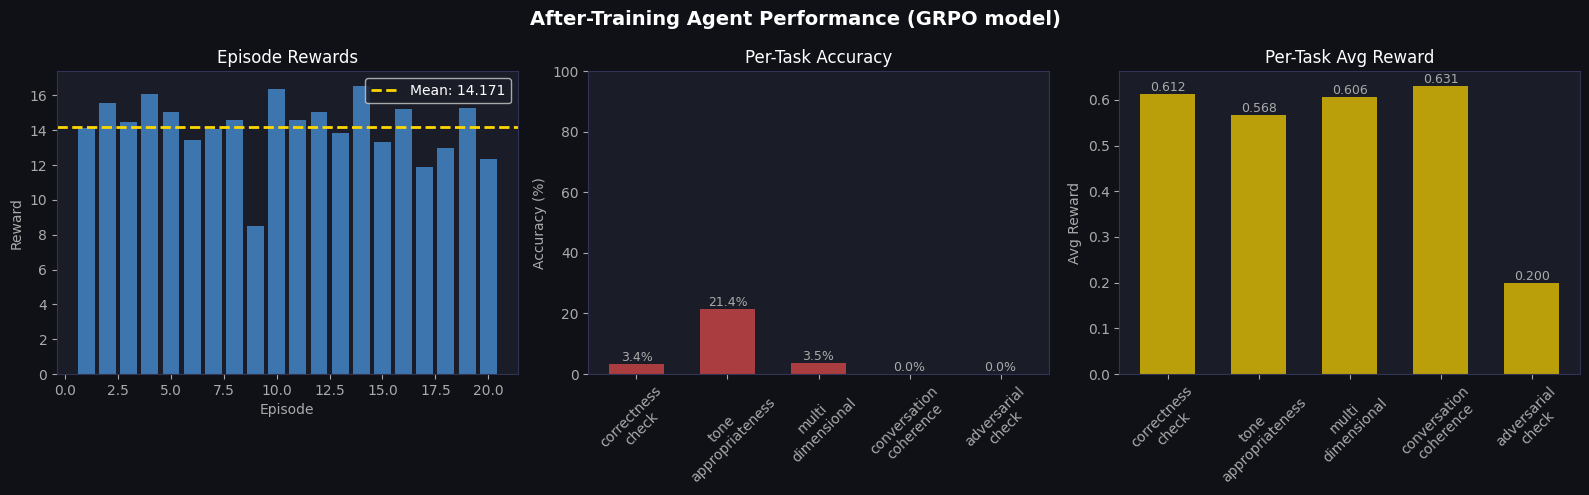

In [17]:
import matplotlib.pyplot as plt
import numpy as np

BG, CARD, BLUE, RED, GOLD, GREY = '#0F1117', '#1A1D27', '#4C9BE8', '#E84C4C', '#FFD700', '#AAAAAA'

episode_rewards  = after_results['overall']['episode_rewards']
task_names       = list(after_results['task_stats'].keys())
task_accuracies  = [after_results['task_stats'][t]['accuracy']   for t in task_names]
task_avg_rewards = [after_results['task_stats'][t]['avg_reward'] for t in task_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
fig.suptitle('After-Training Agent Performance (GRPO model)',
             color='white', fontsize=14, fontweight='bold')

# Plot 1: Episode rewards
ax = axes[0]
ax.set_facecolor(CARD)
episodes = list(range(1, len(episode_rewards) + 1))
ax.bar(episodes, episode_rewards, color=BLUE, alpha=0.7, width=0.8)
mean_r = np.mean(episode_rewards) if episode_rewards else 0.0
ax.axhline(y=mean_r, color=GOLD, linestyle='--', linewidth=2, label=f'Mean: {mean_r:.3f}')
ax.set_title('Episode Rewards', color='white', fontsize=12)
ax.set_xlabel('Episode', color=GREY)
ax.set_ylabel('Reward', color=GREY)
ax.tick_params(colors=GREY)
ax.legend(facecolor=CARD, labelcolor='white', loc='best')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

# Plot 2: Per-task accuracy
ax = axes[1]
ax.set_facecolor(CARD)
task_labels = [t.replace('_', '\n') for t in task_names]
colors = [BLUE if acc >= 50 else RED for acc in task_accuracies]
bars = ax.bar(task_labels, task_accuracies, color=colors, alpha=0.7, width=0.6)
ax.set_title('Per-Task Accuracy', color='white', fontsize=12)
ax.set_ylabel('Accuracy (%)', color=GREY)
ax.set_ylim(0, 100)
ax.tick_params(colors=GREY, axis='x', rotation=45)
ax.tick_params(colors=GREY, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', color=GREY, fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

# Plot 3: Per-task avg reward
ax = axes[2]
ax.set_facecolor(CARD)
bars = ax.bar(task_labels, task_avg_rewards, color=GOLD, alpha=0.7, width=0.6)
ax.set_title('Per-Task Avg Reward', color='white', fontsize=12)
ax.set_ylabel('Avg Reward', color=GREY)
ax.tick_params(colors=GREY, axis='x', rotation=45)
ax.tick_params(colors=GREY, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', color=GREY, fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=150, facecolor=BG, bbox_inches='tight')
print(f'✓ Plot saved to {PLOT_FILE}')
plt.show()

## Summary

| Output | Location | Description |
|---|---|---|
| Detailed scores | `after_training_results/after_training_scores.json` | Episode-by-episode results |
| Performance plot | `after_training_results/after_training_plot.png` | Per-task metrics |

Compare these numbers against `baseline_results/baseline_scores.json` (the
before-training run) to quantify the GRPO improvement. Same `NUM_EPISODES`,
same `STEPS_PER_EPISODE`, same `SYSTEM_PROMPT` — the only difference is the
agent (untrained Qwen2.5-1.5B vs GRPO-trained model on the HF endpoint).